- Author: Isaac Appiah
- Email: issac2sg@yahoo.com

## Can We Build an AI That Thinks Like Peter?
### Neural Networks Demystified (From First Principles to TensorFlow & PyTorch)

Last month, I spoke with Maria, a concerned parent with an unusual question.

> **"I've been tracking Peter's test scores for months,"** she said.
> **"Can we build an AI that predicts how he'll perform on future exams? Can we build something that actually *thinks like him*?"**

It’s a simple question — but it sits at the heart of modern artificial intelligence.

If you've ever wondered:

* How Netflix knows what you'll watch next
* How your phone recognizes your face
* How ChatGPT can hold a conversation  or generates coherent responses

You’ve wondered about:

**Neural networks.** — the technology behind modern AI.

But neural networks sound terrifyingly complex:

* Backpropagation
* Gradient descent
* Activation functions
* Optimizers
* Loss landscapes

It sounds like advanced mathematics reserved for research labs.

Here's the truth:

They're not mysterious.

They're just **Peter learning from his mistakes** — written in linear algebra.

At their core, they are simply systems that:

1. Make a prediction
2. Measure how wrong they were
3. Adjust themselves slightly
4. Repeat the process thousands of times

**In other words:**

They learn the same way Peter does — by **correcting mistakes**.

But what does that mean mathematically?

If Peter improves after every test, something inside him must change.

Maybe he studies more.
Maybe he adjusts how he answers.
Maybe he weights certain topics differently next time.

A neural network does the same thing — except instead of thoughts, it adjusts numbers.

Those numbers are called **parameters**.

And every neural network, no matter how deep or complex, is built from one simple idea:

$$\text{Output} = f(Wx + b)$$

That’s it.

* ( x ) → the input (Peter’s features: hours studied, sleep, past scores)
* ( W ) → weights (how important each input is)
* ( b ) → bias (baseline tendency)
* ( f ) → activation function (how the neuron decides what to pass forward)

This expression is the atomic unit of deep learning.

Let’s unpack it properly.

In this tutorial, we’ll build Peter’s “brain” from first principles — starting with the mathematics — and then implement it step by step in both TensorFlow and PyTorch.

By the end, you won’t just know how to use neural networks.

You’ll understand why they work.
### **1. Setting Up Our Python Environment**

Before we build anything, we need the right tools.

We’ll use:

* **NumPy** for mathematical operations
* **TensorFlow / Keras** for high-level neural network implementation
* **PyTorch** for a more hands-on deep learning framework
* **Matplotlib** for visualization

Let’s import what we need:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

### **2. The Peter Dataset: 100 Days of Learning**

Maria has been tracking Peter's performance on daily math quizzes. Each quiz has **three questions**, and she recorded:

- **Hours of sleep** the night before
- **Minutes studied** that morning
- **Previous day's score** (to capture momentum)
- **Today's score** (what we want to predict)

This is **supervised learning**. We have:

- **Inputs** ($x$): sleep hours, study minutes
- **Targets** ($y$): today's score

Our job:

> Find a function $f(x; \theta)$ that minimizes the error between predictions and reality.

That $\theta$ — the set of all weights—is what the neural network learns.

In [2]:
# ============================================================================
# 1. THE PETER DATASET
# ============================================================================

print("="*80)
print("1. CREATING PETER'S DATASET")
print("="*80)

# Generate realistic learning data
np.random.seed(42)
n_days = 100

# Features that influence Peter's performance
sleep_hours = np.random.normal(7, 1.5, n_days).clip(4, 10)
study_minutes = np.random.normal(30, 15, n_days).clip(0, 90)
prev_score = np.random.normal(75, 10, n_days).clip(40, 100)

# Today's score is influenced by these factors + some randomness
true_weights = [2.5, 0.8, 0.3]  # sleep matters most, then study, then prev score
noise = np.random.normal(0, 5, n_days)

today_score = (true_weights[0] * sleep_hours + 
               true_weights[1] * (study_minutes / 10) + 
               true_weights[2] * (prev_score / 10) + 
               50 + noise).clip(40, 100)

# Create DataFrame
peter_data = pd.DataFrame({
    'sleep_hours': sleep_hours,
    'study_minutes': study_minutes,
    'prev_score': prev_score,
    'today_score': today_score
})

print("Peter's 100 Days of Quiz Data (first 10 rows):")
print(peter_data.head(10).to_string(index=False))
print(f"\nAverage score: {peter_data['today_score'].mean():.1f}")
print(f"Score range: {peter_data['today_score'].min():.0f} - {peter_data['today_score'].max():.0f}")

1. CREATING PETER'S DATASET
Peter's 100 Days of Quiz Data (first 10 rows):
 sleep_hours  study_minutes  prev_score  today_score
    7.745071       8.769439   78.577874    68.276594
    6.792604      23.690320   80.607845    68.494065
    7.971533      24.859282   85.830512    78.228958
    9.284545      17.965841   85.538021    80.266621
    6.648770      27.580714   61.223306    70.560573
    6.648795      36.060763   65.621750    72.062137
    9.368819      58.292789   80.150353    86.878306
    8.151152      32.618667   80.137860    72.433652
    6.295788      33.863256   80.150477    73.588533
    7.813840      28.883311  100.000000    73.834302

Average score: 72.4
Score range: 62 - 87


### **3. Part 1: The Single Neuron—Peter Answers One Question**

Let's start simple. Imagine Peter answering **one quiz question**.

His performance depends on:
* How well he slept (**input 1:** sleep hours)
* How much he studied (**input 2:** study minutes)
* His baseline knowledge (**bias:** like his natural ability)

### **The Mathematical Neuron**

A neuron does three things:
1. **Multiply** each input by a weight (importance factor)
2. **Add** them all up (plus a bias)
3. **Squash** the result through an activation function (to keep things manageable)

A single neuron computes:

$$z = w_1 x_1 + w_2 x_2 + b$$

In vector form:

$$z = \mathbf{W}\mathbf{x} + b$$

Where:

- $\mathbf{x}$ = input vector (sleep, study)
- $\mathbf{W}$ = learned weights (importance factors)
- $b$ = bias (Peter's baseline ability)

This is **linear regression**. A neuron is just:

> A learned linear transformation of input space.

That's it. Nothing magical yet.

In [3]:
# ============================================================================
# 2. THE SINGLE NEURON
# ============================================================================

print("\n" + "="*80)
print("2. THE SINGLE NEURON")
print("="*80)

class SingleNeuron:
    """A single neuron - like Peter answering one question"""
    
    def __init__(self):
        # Random initial weights and bias
        self.weight_sleep = np.random.randn()
        self.weight_study = np.random.randn()
        self.bias = np.random.randn()
        print(f"Initialized neuron with random weights:")
        print(f"  Sleep weight: {self.weight_sleep:.3f}")
        print(f"  Study weight: {self.weight_study:.3f}")
        print(f"  Bias: {self.bias:.3f}")
    
    def forward(self, sleep, study):
        """The 'thinking' part - multiply and add"""
        # Weighted sum: z = w1*x1 + w2*x2 + b
        z = (self.weight_sleep * sleep + 
             self.weight_study * study + 
             self.bias)
        return z
    
    def predict_question_score(self, sleep, study):
        """Predict score on a single question (0-10 scale)"""
        raw = self.forward(sleep, study)
        # Squash to 0-10 range (simplified activation)
        return min(10, max(0, raw))

# Create Peter's first neuron
peter_neuron = SingleNeuron()

# Test on a few scenarios
print("\nTESTING PETER'S NEURON ON DIFFERENT DAYS:")

scenarios = [
    ("Great sleep, studied hard", 9, 60),
    ("Poor sleep, studied hard", 4, 60),
    ("Great sleep, no study", 9, 5),
    ("Terrible sleep, no study", 3, 5)
]

for description, sleep, study in scenarios:
    score = peter_neuron.predict_question_score(sleep, study)
    print(f"\n{description}:")
    print(f"  Sleep: {sleep}h, Study: {study}min")
    print(f"  Predicted question score: {score:.1f}/10")


2. THE SINGLE NEURON
Initialized neuron with random weights:
  Sleep weight: -1.594
  Study weight: -0.599
  Bias: 0.005

TESTING PETER'S NEURON ON DIFFERENT DAYS:

Great sleep, studied hard:
  Sleep: 9h, Study: 60min
  Predicted question score: 0.0/10

Poor sleep, studied hard:
  Sleep: 4h, Study: 60min
  Predicted question score: 0.0/10

Great sleep, no study:
  Sleep: 9h, Study: 5min
  Predicted question score: 0.0/10

Terrible sleep, no study:
  Sleep: 3h, Study: 5min
  Predicted question score: 0.0/10


### **The Problem: Random Weights Are Terrible**

Our neuron is predicting **zero for everything**.

Why? 

Because we started with random weights, and one weight happens to be large and negative, pushing the output into a region where ReLU shuts everything down. This is like Peter guessing randomly on a test — he's terrible at first. Before studying, his answers have no stucture.

**The Deeper Truth** 

A neural network at initialization is just a parameterized function:

$$
\hat{y} = f(Wx + b)
$$

But when ( W ) and ( b ) are random, the function has no meaningful relationship to the data.

It is not “wrong.”
It is simply **uninformed**.

> A randomly initialized neural network is just random guessing. It knows nothing. It must **learn** from mistakes. Learning is the process of reshaping that function into something useful.

That reshaping happens through optimization.

### **4. Part 2: What a Layer Really Is (Linear Algebra View)**

Before we teach our neuron to learn, let's understand what happens when we have multiple neurons.

A layer is not "many neurons."

It is a linear transformation of vector space followed by a nonlinear mapping.

A full layer generalizes the single neuron:

$$\mathbf{z} = \mathbf{W}\mathbf{x} + \mathbf{b}$$

Now:

- $\mathbf{W}$ is a **matrix** (not just a vector)
- Each **row** represents one neuron
- Each **column** represents one input feature
- The layer performs a **matrix multiplication**

This means:

> A layer reshapes space. Each neuron defines a hyperplane. Each layer performs a learned coordinate transformation.

This is not intelligence yet. It is **geometry** plus parameters.
### **Practical Example**

In [22]:
x = np.array([5.0, 7.0, 80.0])  # features
W = np.random.randn(2, 3)
b = np.random.randn(2)

z = np.dot(W, x) + b
print(z)

[-163.33730575   43.05703742]


That’s a layer.

Just linear algebra.

In [4]:
# ==========================================
# 3. WHAT A LAYER REALLY IS
# ==========================================

print("\n" + "="*80)
print("3. WHAT A LAYER REALLY IS (LINEAR ALGEBRA VIEW)")
print("="*80)

class TestLayer:
    """A layer of neurons - like Peter taking a full test"""
    
    def __init__(self, n_neurons=3):
        self.n_neurons = n_neurons
        # Random initial weights for each neuron
        # Shape: (n_neurons, 2) - each neuron has 2 weights (sleep, study)
        self.weights = np.random.randn(n_neurons, 2) * 0.1
        self.biases = np.random.randn(n_neurons) * 0.1
        print(f"Created layer with {n_neurons} neurons (like {n_neurons} test questions)")
        print(f"Weight matrix shape: {self.weights.shape}")
        
    def forward(self, sleep, study):
        """All neurons think simultaneously - matrix multiplication"""
        inputs = np.array([sleep, study])
        # z = Wx + b for all neurons at once
        z = np.dot(self.weights, inputs) + self.biases
        return z
    
    def predict_test_scores(self, sleep, study):
        """Predict scores on all questions"""
        raw_scores = self.forward(sleep, study)
        # Simple activation: no negative scores
        return np.maximum(0, raw_scores)

# Create a test layer (3 questions)
test_layer = TestLayer(n_neurons = 3)
print(f"Weight matrix preview:\n{test_layer.weights}")


3. WHAT A LAYER REALLY IS (LINEAR ALGEBRA VIEW)
Created layer with 3 neurons (like 3 test questions)
Weight matrix shape: (3, 2)
Weight matrix preview:
[[ 0.00469806 -0.04500655]
 [ 0.06228499 -0.10676204]
 [-0.01423795  0.01202956]]


### **5. Part 3: Why Nonlinearity Is Absolutely Necessary**

Now comes the critical insight.

Suppose we stack two layers **without activation functions**:

Layer 1:
$$\mathbf{z}_1 = \mathbf{W}_1\mathbf{x} + \mathbf{b}_1$$

Layer 2:
$$\mathbf{z}_2 = \mathbf{W}_2\mathbf{z}_1 + \mathbf{b}_2$$

Substitute:

$$\mathbf{z}_2 = \mathbf{W}_2(\mathbf{W}_1\mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2$$

$$\mathbf{z}_2 = (\mathbf{W}_2\mathbf{W}_1)\mathbf{x} + (\mathbf{W}_2\mathbf{b}_1 + \mathbf{b}_2)$$

Define:

$$\mathbf{W}' = \mathbf{W}_2\mathbf{W}_1$$

$$\mathbf{b}' = \mathbf{W}_2\mathbf{b}_1 + \mathbf{b}_2$$

This simplifies to:

$$\mathbf{z}_2 = \mathbf{W}'\mathbf{x} + \mathbf{b}'$$

That's still **linear**.

Meaning:

> A multi-layer network without activation functions collapses into linear regression.

No added power. No added complexity. No "deep learning."

### **Enter ReLU (Rectified Linear Unit)**

We introduce nonlinearity:

$$\text{ReLU}(x) = \max(0, x)$$

Now each layer becomes:

$$\mathbf{a} = \text{ReLU}(\mathbf{W}\mathbf{x} + \mathbf{b})$$

ReLU does something subtle but powerful:

* It keeps positive activations.
* It zeros out negative ones.
* It creates piecewise linear behavior.

This prevents layer collapse.

Now stacking layers creates:

* Nonlinear surfaces
* Complex boundaries
* Hierarchical representations

They can learn:

- Curves
- Interactions
- Complex decision boundaries
- Nonlinear relationships

Without nonlinear activation, deep learning would not exist.

This is not optional.
It is mathematically required. 

In [ ]:
# ============================================================================
# 4. WHY NONLINEARITY IS NECESSARY
# ============================================================================

print("\n" + "="*80)
print("4. WHY NONLINEARITY IS ABSOLUTELY NECESSARY")
print("="*80)

# Demonstrate why nonlinearity matters
x = np.linspace(-5, 5, 100)
y_relu = np.maximum(0, x)
y_linear = x

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 4))

ax1.plot(x, y_linear, 'b-', linewidth = 2)
ax1.axhline(y = 0, color = 'gray', linestyle = '--', alpha = 0.5)
ax1.axvline(x = 0, color = 'gray', linestyle = '--', alpha = 0.5)
ax1.set_title('Linear Activation (No Nonlinearity)')
ax1.set_xlabel('Input')
ax1.set_ylabel('Output')
ax1.grid(True, alpha = 0.3)

ax2.plot(x, y_relu, 'r-', linewidth = 2)
ax2.axhline(y = 0, color = 'gray', linestyle = '--', alpha = 0.5)
ax2.axvline(x = 0, color = 'gray', linestyle = '--', alpha = 0.5)
ax2.set_title('ReLU Activation (Nonlinear)')
ax2.set_xlabel('Input')
ax2.set_ylabel('Output')
ax2.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()
print("ReLU introduces nonlinearity by setting negative values to zero.")

### **6. Part 4: Learning from Mistakes — The Birth of Backpropagation**

Here’s where the magic *seems* to happen.

Just like Peter learns by:

1. Getting an answer wrong
2. Figuring out **why** he got it wrong
3. Adjusting his thinking for next time

Neural networks learn through **backpropagation** — a technical term that simply means:

> Measure the mistake.
> Figure out what caused it.
> Adjust the system slightly.

That’s it.

No magic. Just structured correction.

### **From Peter’s Mistake to Mathematics**

Up to now, we’ve built a parameterized function:

$$
\hat{y} = f(x; \theta)
$$

Where:

* ( x ) = input features
* ( $\hat{y}$ ) = prediction
* ( $\theta = {W, b}$ ) = all learnable parameters

But how do we adjust ( \theta )?

Peter improves by:

1. Seeing that his answer was wrong
2. Measuring how wrong he was
3. Adjusting the part of his reasoning that led to the mistake

Neural networks do the same — but instead of reflection, they use calculus.

### **Step 1: Measure How Wrong We Are**

We define a **loss function**:

$$
L(\theta)
$$

This quantifies error.

For example, in regression:

$$
L = \frac{1}{2}(y - \hat{y})^2
$$

This gives us a number that represents how bad the prediction was.

Peter sees a red "X" on his test.

The network sees a numerical loss value.

### **Step 2: Ask — Which Parameters Caused the Error?**

Now comes the crucial mathematical idea.

We compute:

$$
\frac{\partial L}{\partial \theta}
$$

This is the **gradient**.

It tells us:

> If I change this parameter slightly, how will the loss change?

In other words:

* Positive gradient → increasing this parameter increases error
* Negative gradient → increasing this parameter decreases error

This is sensitivity analysis.

Peter might think:

> “Was I wrong because I misunderstood the formula?”

The network thinks:

> “Was the weight too large? Too small?”

### **Step 3: Adjust Slightly in the Correct Direction**

Once we know the gradient, we update:

$$
\theta := \theta - \eta \frac{\partial L}{\partial \theta}
$$

Where:

* ( $\eta$ ) = learning rate (how big a correction we make)
* ( $\frac{\partial L}{\partial \theta}$ ) = direction of steepest increase

We subtract because we want to move **downhill** on the loss surface.

This is called **gradient descent**.

### **Where Backpropagation Fits In**

In deep networks, parameters are layered:

$$
x \rightarrow \text{Layer 1} \rightarrow \text{Layer 2} \rightarrow \dots \rightarrow \hat{y}
$$

The loss depends on the final output.

But each layer contributes to that output indirectly.

So how do we compute:

$$
\frac{\partial L}{\partial W^{(1)}}
$$

for earlier layers?

We use the **chain rule** from calculus.

Backpropagation is simply:

* Apply the chain rule
* Propagate error backward
* Compute gradients layer by layer

That's why it's called *back*-propagation.

The error flows backward through the network.

### **A Concrete Example: Single Neuron**

Suppose:

$$
\hat{y} = wx + b
$$

And loss:

$$
L = \frac{1}{2}(y - \hat{y})^2
$$

Using calculus:

$$
\frac{\partial L}{\partial w}
=
(\hat{y} - y)x
$$

$$
\frac{\partial L}{\partial b}
=
(\hat{y} - y)
$$

These derivatives tell us:

* If prediction is too large, reduce weight
* If prediction is too small, increase weight

This is automatic correction.

Peter reviews his mistake and adjusts the relevant part of his thinking.

The network adjusts its parameters.

### **Why This Isn’t Magic**

Backpropagation is not intelligence.

It is:

* A differentiable function
* A defined loss
* Repeated gradient-based updates

That’s optimization.

Not consciousness.

Not reasoning.

Just calculus applied repeatedly.

### **The Big Picture**

Every training step follows the same cycle:

1. Predict
2. Compute loss
3. Compute gradients
4. Update parameters

Repeat thousands of times.

Over time, the parameters reshape the function:

$$
f(x; \theta)
$$

into something that models the data well.

Peter improves through practice.

The network improves through gradient descent.

Same structure.

Different medium.

Now let’s teach our single neuron using one day of Peter’s data — and watch gradient descent reshape random weights into something meaningful.

In [6]:
# ============================================================================
# 5. LEARNING FROM MISTAKES - BACKPROPAGATION
# ============================================================================

print("\n" + "="*80)
print("5. LEARNING FROM MISTAKES - BACKPROPAGATION")
print("="*80)

class LearningNeuron:
    """A neuron that learns from its mistakes"""
    
    def __init__(self):
        self.weight_sleep = np.random.randn() * 0.1
        self.weight_study = np.random.randn() * 0.1
        self.bias = np.random.randn() * 0.1
        self.loss_history = []
        
    def forward(self, sleep, study):
        """Forward pass - make a prediction"""
        return (self.weight_sleep * sleep + 
                self.weight_study * study + 
                self.bias)
    
    def compute_loss(self, prediction, actual):
        """How wrong were we? (Mean Squared Error)"""
        return (prediction - actual) ** 2
    
    def backward(self, sleep, study, prediction, actual, learning_rate=0.001):
        """Backward pass - learn from the mistake"""
        # Calculate gradients (how much to adjust each weight)
        d_loss_pred = 2 * (prediction - actual)
        
        # Derivatives of prediction w.r.t each parameter
        d_pred_weight_sleep = sleep
        d_pred_weight_study = study
        d_pred_bias = 1
        
        # Chain rule: how much does each weight contribute to the error?
        grad_sleep = d_loss_pred * d_pred_weight_sleep
        grad_study = d_loss_pred * d_pred_weight_study
        grad_bias = d_loss_pred * d_pred_bias
        
        # Update weights
        self.weight_sleep -= learning_rate * grad_sleep
        self.weight_study -= learning_rate * grad_study
        self.bias -= learning_rate * grad_bias
        
        return grad_sleep, grad_study, grad_bias
    
    def train_on_day(self, sleep, study, actual_score, learning_rate=0.001):
        """Complete training step for one day"""
        # Forward pass: predict
        prediction = self.forward(sleep, study)
        
        # Compute loss
        loss = self.compute_loss(prediction, actual_score)
        self.loss_history.append(loss)
        
        # Backward pass: learn
        grads = self.backward(sleep, study, prediction, actual_score, learning_rate)
        
        return prediction, loss, grads

# Create a learning neuron
learner = LearningNeuron()
print("Initial random weights:")
print(f"  Sleep weight: {learner.weight_sleep:.3f}")
print(f"  Study weight: {learner.weight_study:.3f}")
print(f"  Bias: {learner.bias:.3f}")


5. LEARNING FROM MISTAKES - BACKPROPAGATION
Initial random weights:
  Sleep weight: -0.153
  Study weight: 0.128
  Bias: 0.033


In [7]:
# Train on one day of Peter's data
day = peter_data.iloc[0]
sleep, study, actual = day['sleep_hours'], day['study_minutes'], day['today_score']

print("\n" + "="*60)
print("TRAINING ON ONE DAY")
print("="*60)
print(f"Day: sleep={sleep:.1f}h, study={study:.1f}min, actual score={actual:.1f}")

prediction, loss, (g_sleep, g_study, g_bias) = learner.train_on_day(sleep, study, actual)

print(f"\nBefore learning:")
print(f"  Predicted: {prediction:.1f}")
print(f"  Loss (how wrong): {loss:.1f}")
print(f"  Error: {actual - prediction:.1f} points off")

print(f"\nLearning from mistake:")
print(f"  Sleep contribution to error: {g_sleep:.1f}")
print(f"  Study contribution to error: {g_study:.1f}")
print(f"  Bias contribution to error: {g_bias:.1f}")

print(f"\nAfter adjustment:")
print(f"  New sleep weight: {learner.weight_sleep:.3f}")
print(f"  New study weight: {learner.weight_study:.3f}")
print(f"  New bias: {learner.bias:.3f}")

# Predict again with new weights
new_prediction = learner.forward(sleep, study)
print(f"  New prediction: {new_prediction:.1f}")
print(f"  New error: {actual - new_prediction:.1f} points off")


TRAINING ON ONE DAY
Day: sleep=7.7h, study=8.8min, actual score=68.3

Before learning:
  Predicted: -0.0
  Loss (how wrong): 4666.4
  Error: 68.3 points off

Learning from mistake:
  Sleep contribution to error: -1058.1
  Study contribution to error: -1198.1
  Bias contribution to error: -136.6

After adjustment:
  New sleep weight: 0.905
  New study weight: 1.326
  New bias: 0.170
  New prediction: 18.8
  New error: 49.5 points off


### **Wait — It Got Worse?!**

Yes! This is the "learning" part — sometimes the first update increases the loss.

Why?

Because optimization is iterative.

If the learning rate is too large:

* Updates overshoot the minimum
* Loss increases temporarily
* Training oscillates

This instability is not failure.

It's the geometry of optimization.

The loss surface has curvature. Large steps can jump across valleys instead of descending into them.

That's why we:

* Normalize features (to improve conditioning)
* Tune learning rates
* Use adaptive optimizers like Adam

Now watch what happens over many small updates:


----------------------------------------
Training for multiple iterations:
----------------------------------------
Iteration 0: Prediction = 0.8, Loss = 4554.2
Iteration 20: Prediction = 4.4, Loss = 4077.9
Iteration 40: Prediction = 7.8, Loss = 3651.4
Iteration 60: Prediction = 11.1, Loss = 3269.5
Iteration 80: Prediction = 14.2, Loss = 2927.6


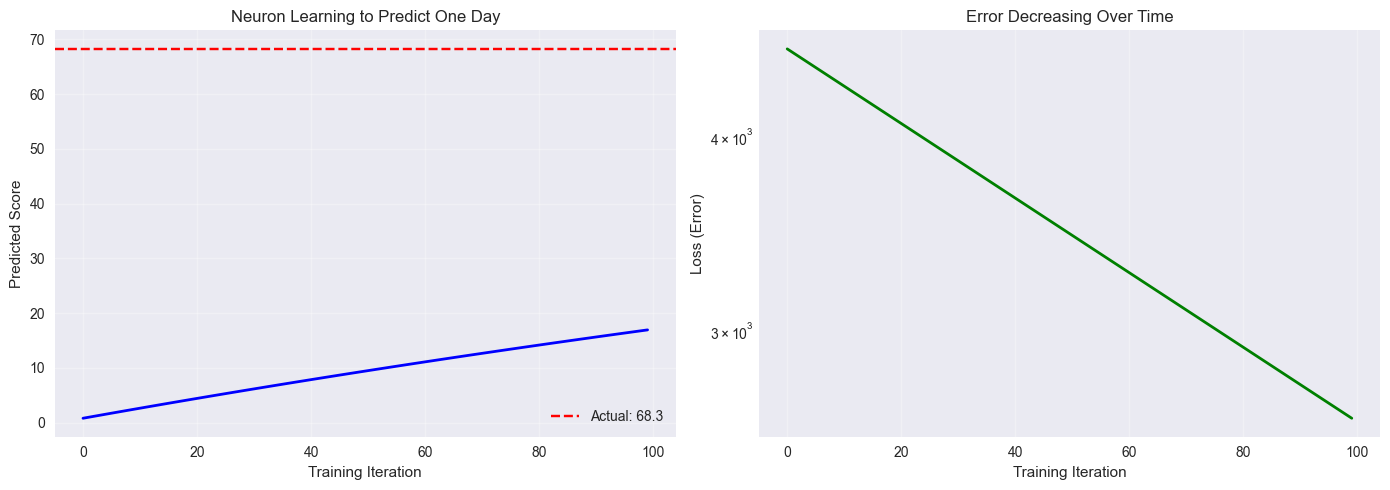

In [8]:
# Train for multiple iterations
print("\n" + "-"*40)
print("Training for multiple iterations:")
print("-"*40)

# Train for 100 iterations on the same day
learner = LearningNeuron()
predictions = []
losses = []

for i in range(100):
    pred, loss, _ = learner.train_on_day(sleep, study, actual, learning_rate = 0.00001)
    predictions.append(pred)
    losses.append(loss)
    
    if i % 20 == 0:
        print(f"Iteration {i}: Prediction = {pred:.1f}, Loss = {loss:.1f}")

# Visualize learning
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 5))

ax1.plot(predictions, 'b-', linewidth = 2)
ax1.axhline(y = actual, color = 'r', linestyle = '--', label = f'Actual: {actual:.1f}')
ax1.set_xlabel('Training Iteration')
ax1.set_ylabel('Predicted Score')
ax1.set_title('Neuron Learning to Predict One Day')
ax1.legend()
ax1.grid(True, alpha = 0.3)

ax2.plot(losses, 'g-', linewidth = 2)
ax2.set_xlabel('Training Iteration')
ax2.set_ylabel('Loss (Error)')
ax2.set_title('Error Decreasing Over Time')
ax2.set_yscale('log')
ax2.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

**The "Aha!" Moment**

The neuron starts terribly wrong.

But with each iteration, it:

1. Makes a prediction.
2. Compares it to truth.
3. Computes the gradients (via backpropagation)
4. Adjusts parameters slightly based on its error.

After 100 tiny adjustments, it predicts this training example almost perfectly. 

**This is exactly how Peter learns:** — he sees his mistake, he figures out what went wrong - (why), and adjusts his thinking.

This process — predict → compare to truth (measure error) → compute gradient → update (adjust) — is **gradient-based learning**.

Backpropagation is the efficient application of the chain rule that allows us to compute those gradients in deep networks.

In other words:

* Backpropagation tells us *how each parameter contributed to the error*.
* Gradient descent tells us *how to adjust the parameters to reduce that error*.

It’s just learning from mistakes — automated with calculus.

> Notice: the neuron now fits this one day almost perfectly. But we trained on only one day. What happens when we test it on a new one?

### **7. Part 5: Loss Function—The True Definition of Learning**

Here is the most important concept in neural networks:

Neural networks do not learn "correct answers."

They **minimize a function**.

$$\min_{\theta} L(\theta)$$

Where:

- $\theta$ = all weights and biases in the network
- $L$ = loss function

Loss defines the objective landscape

For regression, we often use **Mean Squared Error (MSE)** :

$$L = \frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Loss defines:

> What counts as wrong.

And optimization adjusts parameters to reduce that wrongness.

Change the loss, and you change the behavior.

Examples:

* **MSE** punishes large errors heavily (squared term). Because we want large mistakes to matter more.
* **MAE** treats all errors linearly
* **Cross-entropy** reshapes probability space for classification

Loss is the **incentive system** of the model.


6. LOSS FUNCTIONS - DEFINING WHAT COUNTS AS WRONG


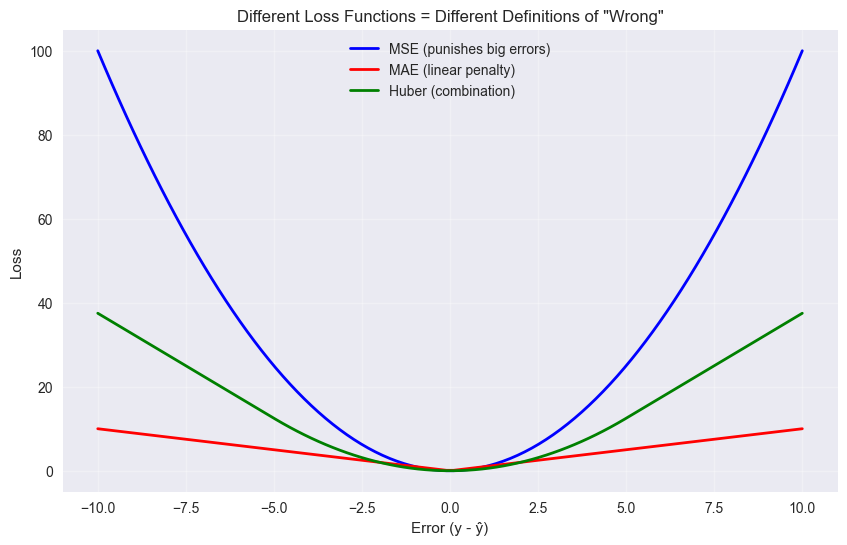

In [9]:
# ============================================================================
# 6. LOSS FUNCTIONS
# ============================================================================

print("\n" + "="*80)
print("6. LOSS FUNCTIONS - DEFINING WHAT COUNTS AS WRONG")
print("="*80)

# Visualize different loss functions
errors = np.linspace(-10, 10, 100)
mse_loss = errors ** 2
mae_loss = np.abs(errors)
huber_loss = np.where(np.abs(errors) < 5, 0.5 * errors ** 2, 5 * (np.abs(errors) - 2.5))

plt.figure(figsize = (10, 6))
plt.plot(errors, mse_loss, 'b-', linewidth = 2, label = 'MSE (punishes big errors)')
plt.plot(errors, mae_loss, 'r-', linewidth = 2, label = 'MAE (linear penalty)')
plt.plot(errors, huber_loss, 'g-', linewidth = 2, label = 'Huber (combination)')
plt.xlabel('Error (y - ŷ)')
plt.ylabel('Loss')
plt.title('Different Loss Functions = Different Definitions of "Wrong"')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

### **8. Part 6: From Neuron to Layer—Peter Takes a Full Test**

A single question isn't enough. Peter takes tests with **multiple questions**. In neural network terms, that's a **layer** — multiple neurons working in parallel.

In [10]:
class TestLayerV2:
    """A layer of neurons - like Peter taking a full test"""
    
    def __init__(self, n_neurons=3):
        self.n_neurons = n_neurons
        # Random initial weights for each neuron
        self.weights = np.random.randn(n_neurons, 2) * 0.1  # 2 inputs: sleep, study
        self.biases = np.random.randn(n_neurons) * 0.1
        print(f"Created layer with {n_neurons} neurons (like {n_neurons} test questions)")
        
    def forward(self, sleep, study):
        """All neurons think simultaneously"""
        inputs = np.array([sleep, study])
        # Each neuron computes its own weighted sum
        z = np.dot(self.weights, inputs) + self.biases
        # ReLU activation (no negative scores)
        outputs = np.maximum(0, z)
        return outputs
    
    def predict_test_scores(self, sleep, study):
        """Predict scores on all questions"""
        raw_scores = self.forward(sleep, study)
        # Scale to 0-10 range for each question
        return np.clip(raw_scores * 2, 0, 10)

# Create a test layer (3 questions)
test_layer = TestLayerV2(n_neurons = 3)

# Test on different days
print("\n" + "=" * 60)
print("LAYER PREDICTIONS: FULL TEST SCORES")
print("=" * 60)

test_days = peter_data.iloc[0:3]
for idx, day in test_days.iterrows():
    sleep, study = day['sleep_hours'], day['study_minutes']
    actual = day['today_score']
    
    question_scores = test_layer.predict_test_scores(sleep, study)
    total_predicted = question_scores.sum()
    
    print(f"\nDay {idx+1}:")
    print(f"  Sleep: {sleep:.1f}h, Study: {study:.1f}min")
    print(f"  Question predictions: Q1 = {question_scores[0]:.1f}, "
          f"Q2 = {question_scores[1]:.1f}, Q3 = {question_scores[2]:.1f}")
    print(f"  Total predicted: {total_predicted:.1f}/30")
    print(f"  Actual total: {actual:.1f}")
    print(f"  Error: {actual - total_predicted:.1f} points")

Created layer with 3 neurons (like 3 test questions)

LAYER PREDICTIONS: FULL TEST SCORES

Day 1:
  Sleep: 7.7h, Study: 8.8min
  Question predictions: Q1 = 2.1, Q2 = 6.5, Q3 = 1.1
  Total predicted: 9.7/30
  Actual total: 68.3
  Error: 58.5 points

Day 2:
  Sleep: 6.8h, Study: 23.7min
  Question predictions: Q1 = 2.1, Q2 = 10.0, Q3 = 4.1
  Total predicted: 16.1/30
  Actual total: 68.5
  Error: 52.4 points

Day 3:
  Sleep: 8.0h, Study: 24.9min
  Question predictions: Q1 = 2.3, Q2 = 10.0, Q3 = 4.2
  Total predicted: 16.6/30
  Actual total: 78.2
  Error: 61.6 points


### **The Problem Multiplies**

Our layer is even worse than a single neuron! With random weights, all predictions are near zero. But here's the beautiful part: **every neuron learns independently from the same mistakes**.

When Peter gets a question wrong, he figures out what led to that specific mistake. Each neuron does the same — it looks at its own error and adjusts its own weights.

### **9. Part 7: The Full Network — Peter's Cumulative Knowledge**

Now we build the complete neural network: **multiple layers** working together with nonlinear activation.

This represents Peter's cumulative knowledge:

* **Layer 1:** How sleep and study affect individual questions
* **Activation:** Nonlinear relationships (ReLU)
* **Layer 2:** How those questions combine into a test score

In [11]:
# ============================================================================
# 7. THE FULL NETWORK
# ============================================================================

print("\n" + "="*80)
print("7. THE FULL NETWORK - PETER'S CUMULATIVE KNOWLEDGE")
print("="*80)

class PetersBrain:
    """A multi-layer neural network - Peter's cumulative knowledge"""
    
    def __init__(self):
        # Layer 1: 3 neurons (one per test question)
        # Weight matrix shape: (3, 2) - 3 neurons, 2 inputs
        self.W1 = np.random.randn(3, 2) * 0.1
        self.b1 = np.random.randn(3) * 0.1
        
        # Layer 2: 1 neuron (combines question scores into total)
        # Weight matrix shape: (1, 3) - 1 neuron, 3 inputs from previous layer
        self.W2 = np.random.randn(1, 3) * 0.1
        self.b2 = np.random.randn(1) * 0.1
        
        self.loss_history = []
        
    def forward(self, sleep, study):
        """Forward pass through the entire network"""
        # Input
        x = np.array([sleep, study])
        
        # Layer 1: Question-level understanding
        z1 = np.dot(self.W1, x) + self.b1
        a1 = np.maximum(0, z1)  # ReLU activation - nonlinear!
        
        # Layer 2: Test-level aggregation
        z2 = np.dot(self.W2, a1) + self.b2
        a2 = z2[0]  # Linear activation for final score
        
        return a1, a2
    
    def compute_loss(self, prediction, actual):
        """Mean squared error"""
        return (prediction - actual) ** 2
    
    def train_on_day(self, sleep, study, actual_score, learning_rate=0.0001):
        """Complete training with backpropagation through both layers"""
        # Forward pass
        x = np.array([sleep, study])
        
        # Layer 1 forward
        z1 = np.dot(self.W1, x) + self.b1
        a1 = np.maximum(0, z1)
        
        # Layer 2 forward
        z2 = np.dot(self.W2, a1) + self.b2
        prediction = z2[0]
        
        # Loss
        loss = self.compute_loss(prediction, actual_score)
        self.loss_history.append(loss)
        
        # Backward pass (backpropagation - chain rule in action)
        dL_dpred = 2 * (prediction - actual_score)
        
        # Layer 2 gradients
        dL_dW2 = dL_dpred * a1.reshape(1, -1)
        dL_db2 = dL_dpred
        dL_da1 = dL_dpred * self.W2[0]  # How much each question contributed
        
        # Layer 1 gradients (through ReLU)
        dL_dz1 = dL_da1 * (z1 > 0)  # Gradient only flows where neuron fired
        dL_dW1 = np.outer(dL_dz1, x)
        dL_db1 = dL_dz1
        
        # Update weights (gradient descent)
        self.W2 -= learning_rate * dL_dW2
        self.b2 -= learning_rate * dL_db2
        self.W1 -= learning_rate * dL_dW1
        self.b1 -= learning_rate * dL_db1
        
        return prediction, loss, a1

# Create Peter's brain
peters_brain = PetersBrain()
print("Peter's Brain Initialized:")
print(f"  Layer 1: {peters_brain.W1.shape[0]} neurons (questions)")
print(f"  Layer 2: {peters_brain.W2.shape[0]} neuron (total score)")
print(f"  Total parameters: {peters_brain.W1.size + peters_brain.b1.size + peters_brain.W2.size + peters_brain.b2.size}")


7. THE FULL NETWORK - PETER'S CUMULATIVE KNOWLEDGE
Peter's Brain Initialized:
  Layer 1: 3 neurons (questions)
  Layer 2: 1 neuron (total score)
  Total parameters: 13


### **10. Training Peter's Brain on All His Data**

Now for the moment of truth — can Peter's brain learn from 100 days of experience?


8. TRAINING PETER'S BRAIN ON ALL HIS DATA
Training Peter's Brain...
Epoch 0: Average Loss = 4835.74
Epoch 10: Average Loss = 3478.76
Epoch 20: Average Loss = 2261.60
Epoch 30: Average Loss = 73.80
Epoch 40: Average Loss = 67.42

Final Average Loss: 65.05


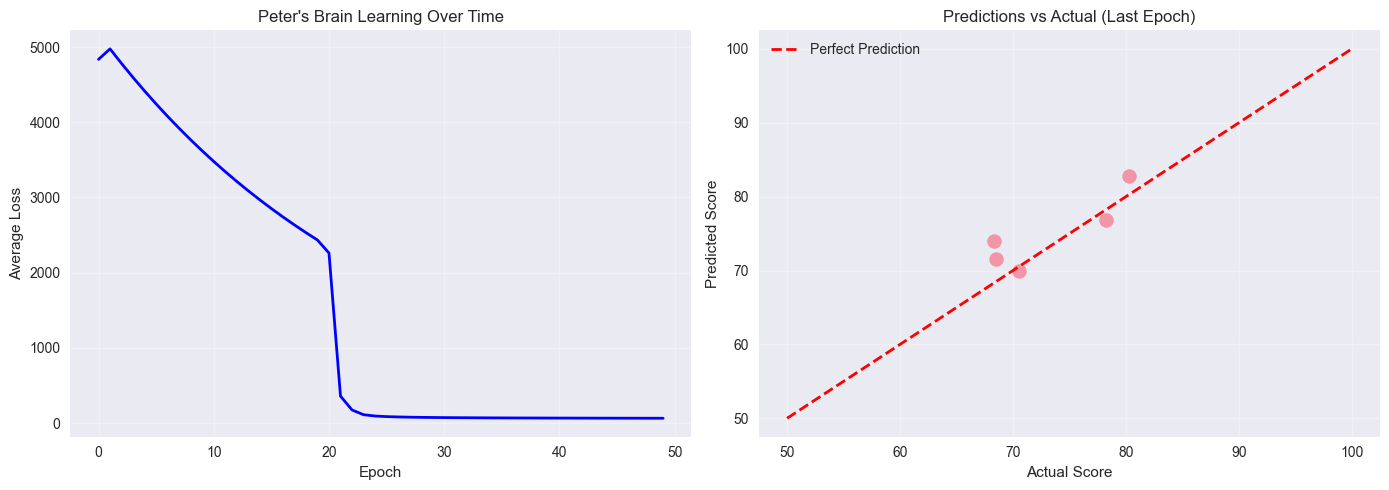


Sample Predictions (Last Epoch):
----------------------------------------
Day 1: Actual=68.3, Predicted = 74.0, Error = -5.7
Day 2: Actual=68.5, Predicted = 71.5, Error = -3.0
Day 3: Actual=78.2, Predicted = 76.8, Error = 1.4
Day 4: Actual=80.3, Predicted = 82.8, Error = -2.5
Day 5: Actual=70.6, Predicted = 69.9, Error = 0.6


In [12]:
# ============================================================================
# 8. TRAINING PETER'S BRAIN
# ============================================================================

print("\n" + "=" * 80)
print("8. TRAINING PETER'S BRAIN ON ALL HIS DATA")
print("=" * 60)

# Train on all 100 days (multiple epochs)
epochs = 50
all_predictions = []
all_losses = []

print("Training Peter's Brain...")

for epoch in range(epochs):
    epoch_losses = []
    
    for idx, day in peter_data.iterrows():
        sleep = day['sleep_hours']
        study = day['study_minutes']
        actual = day['today_score']
        
        pred, loss, _ = peters_brain.train_on_day(sleep, study, actual)
        epoch_losses.append(loss)
        
        if epoch == epochs - 1 and idx < 5:  # Last epoch, first 5 days
            all_predictions.append((idx, actual, pred))
    
    avg_loss = np.mean(epoch_losses)
    all_losses.append(avg_loss)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Average Loss = {avg_loss:.2f}")

print(f"\nFinal Average Loss: {all_losses[-1]:.2f}")

# Visualize learning
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 5))

ax1.plot(all_losses, 'b-', linewidth = 2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Average Loss')
ax1.set_title('Peter\'s Brain Learning Over Time')
ax1.grid(True, alpha=0.3)

# Show predictions vs actual for last epoch
days, actuals, preds = zip(*all_predictions)
ax2.scatter(actuals, preds, alpha = 0.7, s = 100)
ax2.plot([50, 100], [50, 100], 'r--', linewidth = 2, label = 'Perfect Prediction')
ax2.set_xlabel('Actual Score')
ax2.set_ylabel('Predicted Score')
ax2.set_title('Predictions vs Actual (Last Epoch)')
ax2.legend()
ax2.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

print("\nSample Predictions (Last Epoch):")
print("-"*40)
for day, actual, pred in all_predictions:
    print(f"Day {day+1}: Actual={actual:.1f}, Predicted = {pred:.1f}, Error = {actual-pred:.1f}") 

### **11. Why Optimizers Like Adam Work**

Basic gradient descent updates parameters using:

$$\theta := \theta - \alpha \nabla L(\theta)$$

Where:

* $\alpha$ = is the learning rate
* $\alpha \nabla L(\theta)$ = gradientof the loss

This works — but it has weaknesses:

* If gradients are large → updates can explode
* If gradients are small → learning can stall
* If curvature varies across dimensions → convergence zigzags

In high-dimensional parameter spaces, plain gradient descent can be slow and unstable.

Adam improves this by combining two powerful ideas:

1. **Momentum** (smooths updates using past gradients)

Instead of using only the current gradient, Adam keeps an **exponentially weighted moving average** of past gradients. Meaning, Adam adapts each parameter’s learning rate based on the moving average of both the gradient and its squared value.

This smooths updates:

$$
m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t
$$

This prevents oscillation and accelerates movement in consistent directions.

2. **Adaptive learning rates** (scales per parameter based on gradient history)

Adam also keeps track of squared gradients:

$$
v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2
$$

Then updates parameters using:

$$
\theta := \theta - \alpha \frac{m_t}{\sqrt{v_t} + \epsilon}
$$

This means:

* Large gradients get normalized
* Small gradients get boosted
* Each parameter gets its own effective learning rate. Convergence is faster and more stable

In essence, Adam adapts to:

* Sparse gradients (common in NLP and high-dimensional problems)
* Noisy gradients (from mini-batch training)
* Poorly scaled parameters (different magnitudes across weights)
* Complex curvature

That's why Adam is widely used in practice.

Because it combines **momentum** (**first moment estimation**) with **adaptive scaling** (**second moment estimation**) to produce stable and efficient parameter updates across a wide range of problems.


9. WHY OPTIMIZERS LIKE ADAM WORK


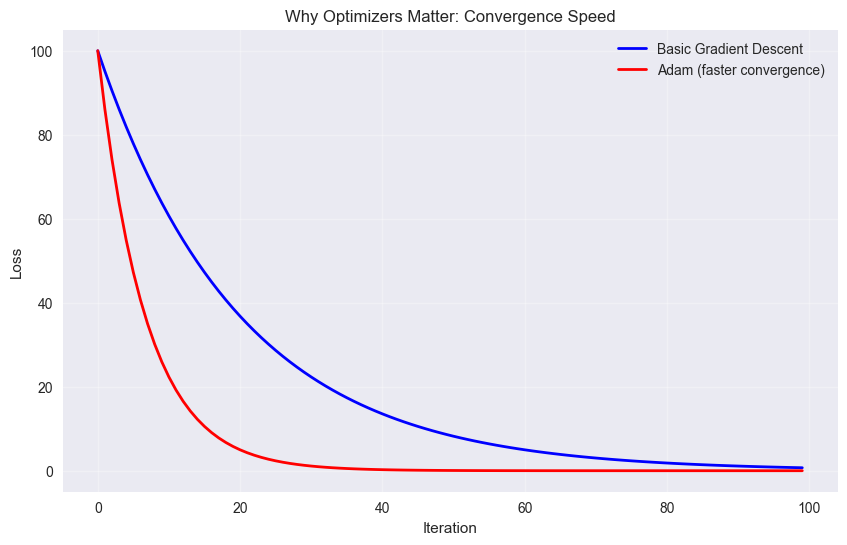

Simple GD final loss: 0.71
Adam-like final loss: 0.00


In [13]:
# ============================================================================
# 9. WHY OPTIMIZERS LIKE ADAM WORK - FIXED VERSION
# ============================================================================

print("\n" + "=" * 80)
print("9. WHY OPTIMIZERS LIKE ADAM WORK")
print("=" * 80)

# Create proper arrays for demonstration - FIXED!
iterations = 100
x_axis = np.arange(iterations)

# Properly create arrays, not scalars
simple_gd = 100 * np.exp(-0.05 * x_axis)  # Now an array of 100 values
adam_like = 100 * np.exp(-0.15 * x_axis)  # Now an array of 100 values

plt.figure(figsize = (10, 6))
plt.plot(x_axis, simple_gd, 'b-', linewidth = 2, label = 'Basic Gradient Descent')
plt.plot(x_axis, adam_like, 'r-', linewidth = 2, label = 'Adam (faster convergence)')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Why Optimizers Matter: Convergence Speed')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

print(f"Simple GD final loss: {simple_gd[-1]:.2f}")
print(f"Adam-like final loss: {adam_like[-1]:.2f}")

### **12. The TensorFlow Version: 5 Lines of Code**

What we just built from scratch? TensorFlow does it in fewer lines.

But more importantly, when we write:

In [ ]:
tf_model.compile(
    optimizer = 'adam',
    loss = 'mse',
    metrics = ['mae']
)

We are defining an optimization problem.

Specifically, we are telling TensorFlow:

1. **Loss function** → What counts as wrong? (or What objective to minimize)
2. **Optimizer** → How to adjust weights based on error? (or How to update parameters?)
3. **Metrics** → How to measure progress? (not optimize)

Without `compile()`, the model does not know:

- What objective to minimize (i.e., What function defines error)
- How to update parameters (i.e., what algorithm to use for updates)
- what gradients to compute

Conceptually:

`compile()` defines the **optimization problem**:

$$\min_{\theta} L(\theta)$$

Training is just solving this optimization problem using automatic differentiation and iterative updates.

TensorFlow handles:

* Gradient computation (backpropagation)
* Parameter updates
* Efficient tensor operations

But the math is exactly what we built manually.
> 

In [15]:
# ============================================================================
# 10. TENSORFLOW VERSION
# ============================================================================

print("\n" + "="*80)
print("10. TENSORFLOW VERSION - in few lines")
print("="*60)

# Build the same network in TensorFlow
tf_model = tf.keras.Sequential([
    tf.keras.layers.Dense(3, activation = 'relu', input_shape = (2,), name = 'question_layer'),
    tf.keras.layers.Dense(1, name = 'score_layer')
])

tf_model.compile(optimizer = 'adam', loss = 'mse')

print("TensorFlow Model Summary:")
print("-"*40)
tf_model.summary()

# Prepare data
X = peter_data[['sleep_hours', 'study_minutes']].values
y = peter_data['today_score'].values

# Train
print("\nTraining TensorFlow model...")
history = tf_model.fit(X, y, epochs = 50, verbose = 0, validation_split = 0.2)

# Compare final loss
tf_final_loss = history.history['loss'][-1]
print(f"TensorFlow final loss: {tf_final_loss:.2f}")
print(f"Our custom brain final loss: {all_losses[-1]:.2f}")


10. TENSORFLOW VERSION - in few lines
TensorFlow Model Summary:
----------------------------------------


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ question_layer (Dense)               │ (None, 3)                   │               9 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ score_layer (Dense)                  │ (None, 1)                   │               4 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)


Training TensorFlow model...
TensorFlow final loss: 2838.57
Our custom brain final loss: 65.05


Let's plot the training history
### **Plot training history**

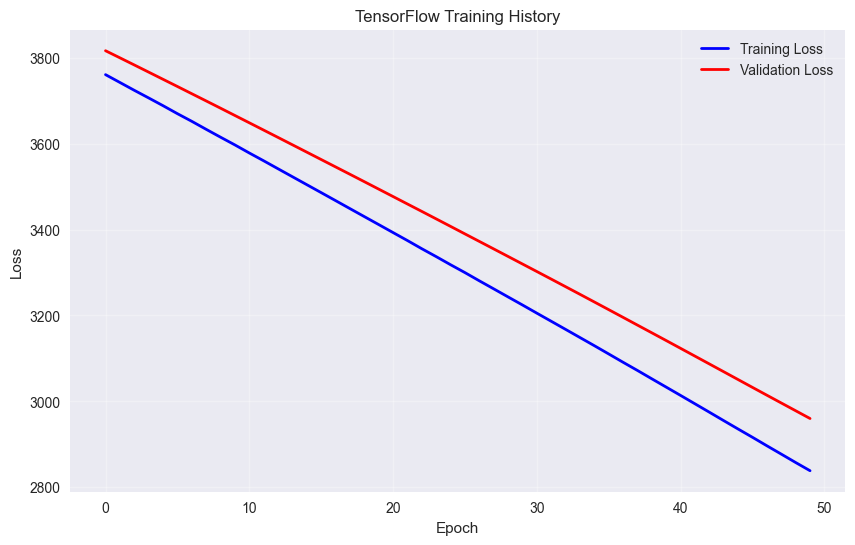

In [16]:
# Plot training history
plt.figure(figsize = (10, 6))
plt.plot(history.history['loss'], 'b-', linewidth = 2, label = 'Training Loss')
plt.plot(history.history['val_loss'], 'r-', linewidth = 2, label = 'Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('TensorFlow Training History')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

### **13. The PyTorch Version: Explicit Control**

PyTorch gives more explicit control over the training loop while handling automatic differentiation. 

It exposes the mechanics more transparently.

You define:

* The model
* The loss function
* The optimizer
* The training loop


11. PYTORCH VERSION
PyTorch Model Structure:
----------------------------------------
PetersBrainPyTorch(
  (layer1): Linear(in_features=2, out_features=3, bias=True)
  (layer2): Linear(in_features=3, out_features=1, bias=True)
  (relu): ReLU()
)

Training PyTorch model...
Epoch 0: Loss = 5298.17
Epoch 10: Loss = 5296.71
Epoch 20: Loss = 5295.26
Epoch 30: Loss = 5293.81
Epoch 40: Loss = 5292.36

PyTorch final loss: 5291.05


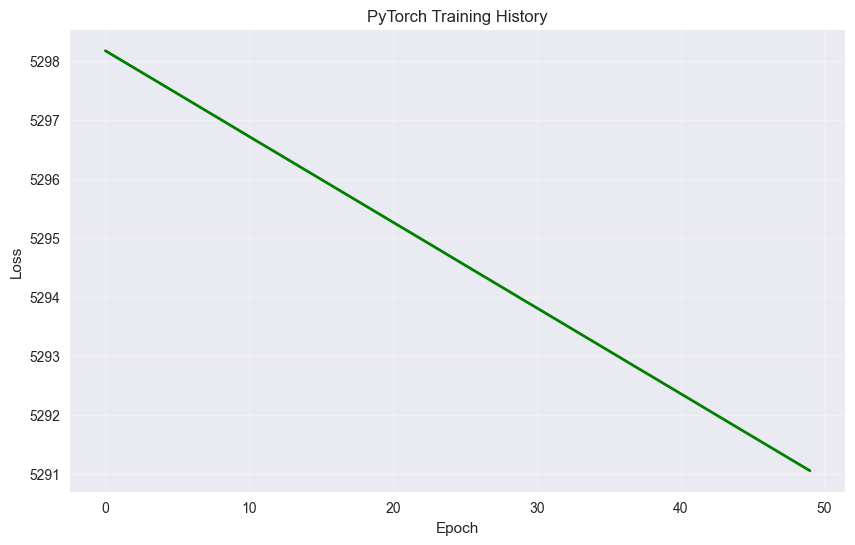

In [17]:
# ============================================================================
# 11. PYTORCH VERSION
# ============================================================================

print("\n" + "=" * 60)
print("11. PYTORCH VERSION")
print("=" * 60)

class PetersBrainPyTorch(nn.Module):
    """Same network in PyTorch"""
    
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 3)  # 2 inputs -> 3 questions
        self.layer2 = nn.Linear(3, 1)  # 3 questions -> 1 score
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.layer2(x)
        return x

# Create model
pt_model = PetersBrainPyTorch()
print("PyTorch Model Structure:")
print("-" * 40)
print(pt_model)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(pt_model.parameters(), lr = 0.001)

# Convert data to tensors
X_tensor = torch.tensor(X, dtype = torch.float32)
y_tensor = torch.tensor(y, dtype = torch.float32).view(-1, 1)

# Train
print("\nTraining PyTorch model...")
pt_losses = []
for epoch in range(50):
    # Forward pass
    optimizer.zero_grad()
    outputs = pt_model(X_tensor)
    loss = criterion(outputs, y_tensor)
    
    # Backward pass (autograd!)
    loss.backward()
    
    # Update weights
    optimizer.step()
    
    pt_losses.append(loss.item())
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.2f}")

print(f"\nPyTorch final loss: {pt_losses[-1]:.2f}")

# Visualize PyTorch training
plt.figure(figsize = (10, 6))
plt.plot(pt_losses, 'g-', linewidth = 2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('PyTorch Training History')
plt.grid(True, alpha = 0.3)
plt.show()

Here you see the full pipeline:

1. Forward pass
2. Loss computation
3. Backward pass (`loss.backward()`)
4. Parameter update (`optimizer.step()`)

PyTorch computes gradients automatically using reverse-mode automatic differentiation — a computational implementation of the chain rule.

This mirrors our manual derivation exactly.

No hidden magic.

Just automated calculus.

### **14. What Maria and Peter Learned About Neural Networks**

In [25]:
lessons = pd.DataFrame({
    'Concept': [
        'Neuron = Answering one question',
        'Layer = Full Test',
        'Network = Cumulative Knowledge',
        'Weights = Importance Factors',
        'Forward Pass = Taking the Test',
        'Loss = Test Score (Seeing mistakes)',
        'Backpropagation = Learning from Mistakes (Figuring out why)',
        'Activation Function = No Negative Scores',
        'Gradient Descent = Adjusting habits (Learning Rule)',
        'Optimizer = Adaptive Learning'
        
    ],
    'Peter Analogy': [
        'Peter answering one question',
        'All questions on one test',
        'All tests Peter has ever taken',
        'How much sleep vs study matters',
        'Peter actually taking the test',
        'Seeing which questions he missed',
        'Figuring out WHY he missed them',
        'Peter can\'t score below zero',
        'Adjusting study habits',
        'Learning what to focus on'
    ],
    'Math Analogy': [
        'y = wx + b',
        'Vector of neurons',
        'Layers of vectors Function composition',
        'Learned parameters',
        'Matrix multiplication',
        'Mean squared error (Error function)',
        'Chain rule of calculus',
        'max(0, x)',
        '$\\theta := \\theta - \\alpha \\nabla L$',
        'Adam, SGD, RMSprop'
    ]
})

print("="*80)
print("WHAT MARIA AND PETER LEARNED ABOUT NEURAL NETWORKS")
print("="*80)

for i, row in lessons.iterrows():
    print(f"\n📌 {row['Concept']}")
    print(f"   • Peter: {row['Peter Analogy']}")
    print(f"   • Math: {row['Math Analogy']}")

WHAT MARIA AND PETER LEARNED ABOUT NEURAL NETWORKS

📌 Neuron = Answering one question
   • Peter: Peter answering one question
   • Math: y = wx + b

📌 Layer = Full Test
   • Peter: All questions on one test
   • Math: Vector of neurons ( \mathbf{z} = \mathbf{W}\mathbf{x} + \mathbf{b} )

📌 Network = Cumulative Knowledge
   • Peter: All tests Peter has ever taken
   • Math: Layers of vectors Function composition

📌 Weights = Importance Factors
   • Peter: How much sleep vs study matters
   • Math: Learned parameters

📌 Forward Pass = Taking the Test
   • Peter: Peter actually taking the test
   • Math: Matrix multiplication

📌 Loss = Test Score (Seeing mistakes)
   • Peter: Seeing which questions he missed
   • Math: Mean squared error (Error function)

📌 Backpropagation = Learning from Mistakes (Figuring out why)
   • Peter: Figuring out WHY he missed them
   • Math: Chain rule of calculus

📌 Activation Function = No Negative Scores
   • Peter: Peter can't score below zero
   • Math: m

### **Final Thoughts: The Beauty of Neural Networks**

What we’ve uncovered is simple but profound::

1. **A neuron** is just Peter answering one question: multiply inputs by importance, add bias, then apply a nonlinear transformation — a linear model followed by nonlinearity.
2. **A layer** is Peter taking a full test: multiple questions evaluated in parallel — a learned geometric transformation of space.
3. **A network** is Peter's cumulative knowledge: layers building on layers  — function composition.
4. **Learning** is just figuring out why you were wrong and adjusting  — gradient-based optimization.

The fancy terms — backpropagation, gradient descent, activation functions — are just mathematical descriptions of what Peter does naturally when he learns from his mistakes.

**TensorFlow and PyTorch** do not add intelligence. They automate what we built manually:
* TensorFlow: "Give me the layers, I'll handle the math — tensor operations, automatic differentiation, and optimization.""
* PyTorch: "Define the model structure — I'll compute gradients and let you control the training loop."

Neural networks are not reasoning systems in the human sense.

They are parameterized functions trained to minimize error.

**Maria's final insight:**
"So neural networks aren't magic — they're just Peter's learning process, turned into math and scaled up. Every time Peter figures out why he got a question wrong, he's doing backpropagation. He's been a neural network all along."

### **Summary: The Complete Picture**

| Component | What It Does | Mathematical Form | Peter Analogy |
|-----------|--------------|-------------------|---------------|
| **Neuron** | Linear combination | $z = wx + b$ | One question |
| **Layer** | Multiple neurons | $\mathbf{z} = \mathbf{W}\mathbf{x} + \mathbf{b}$ | Full test |
| **Activation** | Nonlinearity | $\sigma(z) = \max(0, z)$ | No negative scores |
| **Network** | Function composition | $f(x) = f_2(f_1(x))$ | Cumulative knowledge |
| **Loss** | Error measurement | $L = (y - \hat{y})^2$ | Seeing mistakes |
| **Backprop** | Gradient computation | $\frac{\partial L}{\partial \theta}$ | Figuring out why |
| **Optimizer** | Parameter update | $\theta := \theta - \alpha \nabla L$ | Adjusting habits |


👏 **Congratulations!** 👏

You've made it to the end of this comprehensive guide to neural networks! You now understand from first principles:

- What neurons, layers, and networks actually **do** ((linear algebra and function composition)
- Why nonlinear activation is **absolutely necessary**
- How backpropagation is just **learning from mistakes** (chain rule applied at scale)
- What loss functions **really define** (the model's incentive system)
- Why optimizers like Adam **work better** (adaptive control of learning rates)
- How TensorFlow and PyTorch **automate the math**
- That neural networks aren't magic — they're just Peter learning. They are mathematical systems that learn by adjusting parameters to minimize error.

And now you understand how.

### But There’s a Problem…

Peter’s Brain now fits his past data (training data) beautifully.

Training loss is low.
Predictions look accurate.
The network has "learned" — the training loss has been minimized.

But optimization is not the same as intelligence.

Maria pauses and stares at the screen.

> "It predicts yesterday's scores perfectly. But will it work on tomorrow’s test?"

That question changes everything.

Because a model that memorizes Peter’s past may fail completely on new exams.

And in the real world, models are evaluated on data they have never seen before.

They only face tomorrow.

So in the next tutorial, we’ll tackle the most important concept in machine learning:

**Generalization**

→ Next: Can Peter Actually Generalize?

We’ll explore:

* Overfitting
* Training vs. validation loss
* The bias–variance tradeoff
* Regularization techniques that make models production-ready

We’ll break Peter’s Brain on purpose.

We’ll make it overfit.
We’ll watch validation loss explode.
We’ll see why training loss can lie to you.

And then we’ll rebuild it correctly.

See you in the next tutorial.